<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/08_external_sector_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_trade_data = """Month,Merchandise_Exports_Billion,Merchandise_Imports_Billion,Brent_Crude_USD,USD_INR_Exchange_Rate
2024-01-01,36.92,53.40,79.15,83.12
2024-02-01,41.40,60.11,81.72,82.97
2024-03-01,41.68,57.28,85.41,83.05
2024-04-01,34.99,54.09,89.94,83.40
2024-05-01,38.13,61.91,83.00,83.35
2024-06-01,35.20,56.18,82.55,83.54
2024-07-01,34.71,57.48,83.88,83.72
2024-08-01,34.71,64.36,78.88,83.90
2024-09-01,34.58,55.36,72.87,83.75
2024-10-01,39.20,65.03,75.38,84.07
2024-11-01,32.14,56.87,73.20,84.45
2024-12-01,38.40,58.20,74.10,84.85
2025-01-01,36.50,59.30,78.40,85.20
2025-02-01,37.10,57.80,76.50,85.60
"""

with open("external_sector_data.csv", "w") as f:
    f.write(raw_trade_data.strip())

print("external_sector_data.csv created successfully.")

external_sector_data.csv created successfully.


In [2]:
df_trade = pd.read_csv("external_sector_data.csv")
df_trade["Month"] = pd.to_datetime(df_trade["Month"])

# 1. Calculate Merchandise Trade Balance (Exports - Imports)
# Negative values represent trade deficits
df_trade["Trade_Balance_Billion"] = (
    df_trade["Merchandise_Exports_Billion"]
    - df_trade["Merchandise_Imports_Billion"]
)
df_trade["Trade_Deficit_Billion"] = df_trade["Trade_Balance_Billion"].abs()

# 2. Export-to-Import Cover Ratio (%)
df_trade["Import_Cover_Ratio_%"] = (
    df_trade["Merchandise_Exports_Billion"]
    / df_trade["Merchandise_Imports_Billion"]
) * 100

# 3. Create 1-month lagged crude oil price to test delayed currency impact
df_trade["Brent_Crude_Lag1"] = df_trade["Brent_Crude_USD"].shift(1)

# 4. Month-over-Month % change in USD/INR and Crude
df_trade["USD_INR_MoM_%"] = (
    df_trade["USD_INR_Exchange_Rate"].pct_change() * 100
)
df_trade["Crude_MoM_%"] = df_trade["Brent_Crude_USD"].pct_change() * 100

print("--- External Sector Pipeline Preview ---")
print(
    df_trade[
        [
            "Month",
            "Trade_Balance_Billion",
            "Import_Cover_Ratio_%",
            "Brent_Crude_USD",
            "USD_INR_Exchange_Rate",
        ]
    ].round(2)
)

--- External Sector Pipeline Preview ---
        Month  Trade_Balance_Billion  Import_Cover_Ratio_%  Brent_Crude_USD  \
0  2024-01-01                 -16.48                 69.14            79.15   
1  2024-02-01                 -18.71                 68.87            81.72   
2  2024-03-01                 -15.60                 72.77            85.41   
3  2024-04-01                 -19.10                 64.69            89.94   
4  2024-05-01                 -23.78                 61.59            83.00   
5  2024-06-01                 -20.98                 62.66            82.55   
6  2024-07-01                 -22.77                 60.39            83.88   
7  2024-08-01                 -29.65                 53.93            78.88   
8  2024-09-01                 -20.78                 62.46            72.87   
9  2024-10-01                 -25.83                 60.28            75.38   
10 2024-11-01                 -24.73                 56.51            73.20   
11 2024-12-

In [3]:
# 1. Total and average trade deficits over the period
total_deficit = df_trade["Trade_Deficit_Billion"].sum()
avg_monthly_deficit = df_trade["Trade_Deficit_Billion"].mean()
avg_cover = df_trade["Import_Cover_Ratio_%"].mean()

print(f"Total Cumulative Deficit: ${total_deficit:,.2f} Billion")
print(f"Average Monthly Deficit:  ${avg_monthly_deficit:.2f} Billion")
print(f"Average Import Coverage:  {avg_cover:.2f}%\n")

# 2. Correlation between Trade Deficit and Currency Depreciation
corr_deficit_inr = df_trade["Trade_Deficit_Billion"].corr(
    df_trade["USD_INR_Exchange_Rate"]
)
corr_crude_inr = df_trade["Brent_Crude_USD"].corr(
    df_trade["USD_INR_Exchange_Rate"]
)
corr_lagged_crude_inr = df_trade["Brent_Crude_Lag1"].corr(
    df_trade["USD_INR_Exchange_Rate"]
)

print(
    f"Correlation (Trade Deficit vs USD/INR):      {corr_deficit_inr:.2f}"
)
print(
    f"Correlation (Brent Crude vs USD/INR):        {corr_crude_inr:.2f}"
)
print(
    f"Correlation (1-Month Lagged Crude vs USD/INR): {corr_lagged_crude_inr:.2f}"
)

Total Cumulative Deficit: $301.71 Billion
Average Monthly Deficit:  $21.55 Billion
Average Import Coverage:  63.21%

Correlation (Trade Deficit vs USD/INR):      0.32
Correlation (Brent Crude vs USD/INR):        -0.57
Correlation (1-Month Lagged Crude vs USD/INR): -0.61


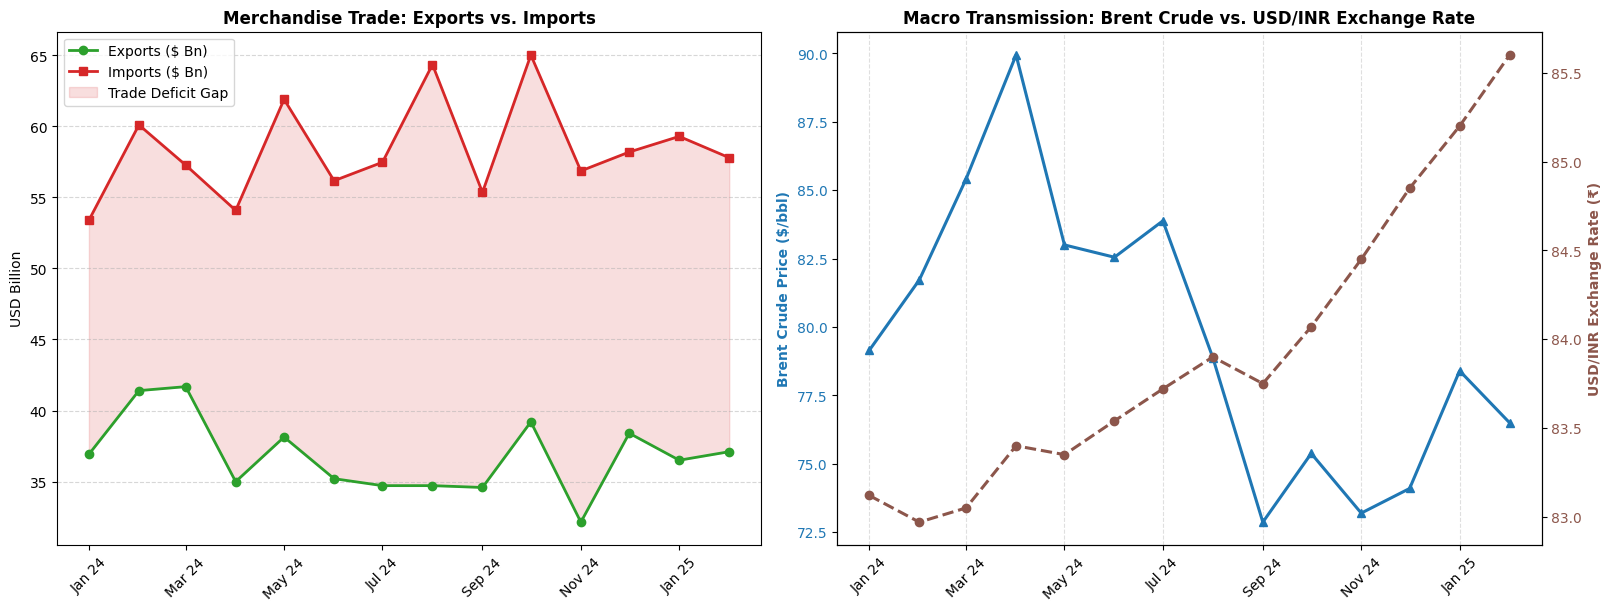

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Merchandise Trade Balance (Stacked / Area View) ---
ax1.plot(
    df_trade["Month"],
    df_trade["Merchandise_Exports_Billion"],
    color="#2ca02c",
    linewidth=2,
    marker="o",
    label="Exports ($ Bn)",
)
ax1.plot(
    df_trade["Month"],
    df_trade["Merchandise_Imports_Billion"],
    color="#d62728",
    linewidth=2,
    marker="s",
    label="Imports ($ Bn)",
)
ax1.fill_between(
    df_trade["Month"],
    df_trade["Merchandise_Exports_Billion"],
    df_trade["Merchandise_Imports_Billion"],
    color="#d62728",
    alpha=0.15,
    label="Trade Deficit Gap",
)

ax1.set_title(
    "Merchandise Trade: Exports vs. Imports", fontsize=12, weight="bold"
)
ax1.set_ylabel("USD Billion")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# --- Chart 2: Dual-Axis Transmission (Brent Crude vs USD/INR) ---
color_crude = "#1f77b4"
ax2.plot(
    df_trade["Month"],
    df_trade["Brent_Crude_USD"],
    color=color_crude,
    linewidth=2.2,
    linestyle="-",
    marker="^",
    label="Brent Crude ($/bbl)",
)
ax2.set_ylabel("Brent Crude Price ($/bbl)", color=color_crude, weight="bold")
ax2.tick_params(axis="y", labelcolor=color_crude)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="x", linestyle="--", alpha=0.4)

# Create twin y-axis sharing the same x-axis
ax2_twin = ax2.twinx()
color_inr = "#8c564b"
ax2_twin.plot(
    df_trade["Month"],
    df_trade["USD_INR_Exchange_Rate"],
    color=color_inr,
    linewidth=2.2,
    linestyle="--",
    marker="o",
    label="USD/INR Exchange Rate",
)
ax2_twin.set_ylabel(
    "USD/INR Exchange Rate (₹)", color=color_inr, weight="bold"
)
ax2_twin.tick_params(axis="y", labelcolor=color_inr)

ax2.set_title(
    "Macro Transmission: Brent Crude vs. USD/INR Exchange Rate",
    fontsize=12,
    weight="bold",
)

plt.show()